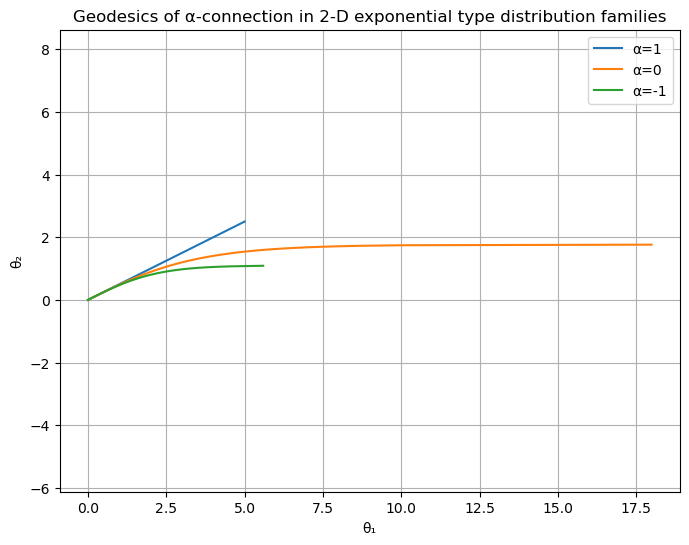

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def p(theta):
    return np.exp(theta) / (1 + np.exp(theta))

def Gamma_diag(theta, alpha):
    pt = p(theta)
    return 0.5 * (1 - alpha) * (1 - 2 * pt)

def geodesic_equation_2d(t, y, alpha):
    theta1, theta2, v1, v2 = y
    dtheta1_dt = v1
    dtheta2_dt = v2
    dv1_dt = -Gamma_diag(theta1, alpha) * v1**2
    dv2_dt = -Gamma_diag(theta2, alpha) * v2**2
    return [dtheta1_dt, dtheta2_dt, dv1_dt, dv2_dt]

def solve_geodesic_2d(alpha, theta0=(0.0, 0.0), v0=(1.0, 0.5), t_span=(0, 5), num_points=200):
    y0 = list(theta0) + list(v0)
    sol = solve_ivp(geodesic_equation_2d, t_span, y0, t_eval=np.linspace(*t_span, num_points), args=(alpha,))
    return sol.y[0], sol.y[1]  # theta1(t), theta2(t)

plt.figure(figsize=(8, 6))
for alpha in [1, 0, -1]:
    theta1, theta2 = solve_geodesic_2d(alpha)
    plt.plot(theta1, theta2, label=f"α={alpha}")

plt.xlabel("θ₁")
plt.ylabel("θ₂")
plt.title("Geodesics of α-connection in 2-D exponential type distribution families")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.show()

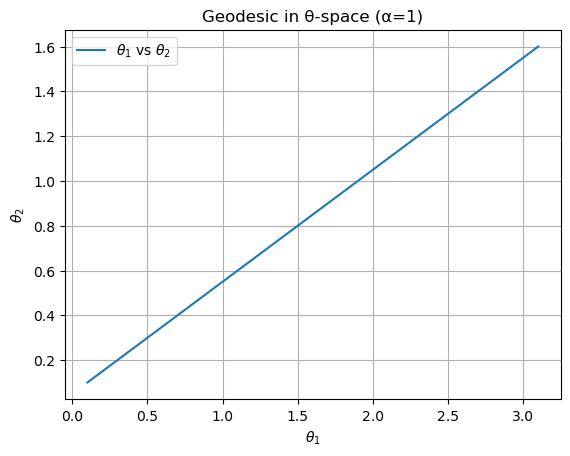

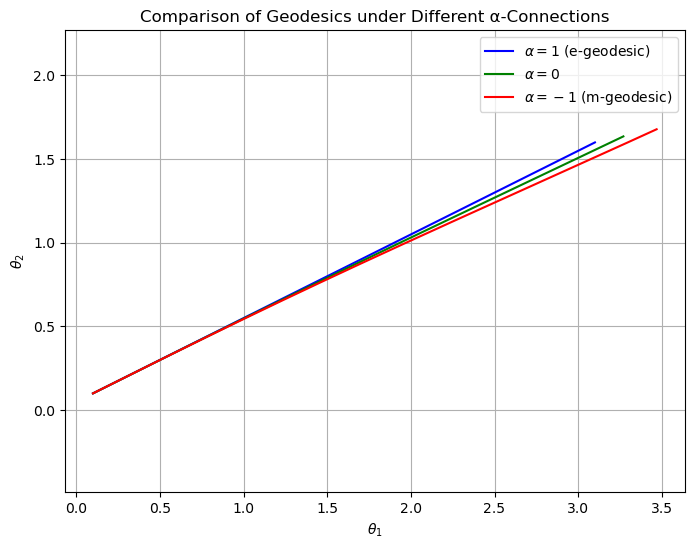

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

x_vals = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])

def psi(theta):
    theta1, theta2, theta12 = theta
    x = x_vals
    exponent = theta1 * x[:, 0] + theta2 * x[:, 1] + theta12 * x[:, 0] * x[:, 1]
    return np.log(np.sum(np.exp(exponent)))

def hessian_psi(theta, eps=1e-4):
    n = len(theta)
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            e_i = np.zeros(n)
            e_j = np.zeros(n)
            e_i[i] = 1
            e_j[j] = 1
            fpp = psi(theta + eps * (e_i + e_j))
            fpm = psi(theta + eps * e_i - eps * e_j)
            fmp = psi(theta - eps * e_i + eps * e_j)
            fmm = psi(theta - eps * (e_i + e_j))
            H[i, j] = (fpp - fpm - fmp + fmm) / (4 * eps**2)
    return H

def geodesic_rhs(t, y, alpha):
    theta = y[:3]
    v = y[3:]
    G = hessian_psi(theta)
    Ginv = np.linalg.inv(G)
    acc = np.zeros(3)
    eps = 1e-4

    for k in range(3):
        sum_term = 0.0
        for i in range(3):
            for j in range(3):
                # 数値微分 ∂G_ij / ∂θ_k
                e_k = np.zeros(3)
                e_k[k] = 1.0
                G_plus = hessian_psi(theta + eps * e_k)
                G_minus = hessian_psi(theta - eps * e_k)
                dG = (G_plus - G_minus) / (2 * eps)

                sum_term += dG[i, j] * v[i] * v[j]

        # acc[k] = -0.5 * (1 - alpha) * Σ_l Ginv[k, l] * sum_term_l
        acc[k] = -0.5 * (1 - alpha) * sum_term  # sum_term はスカラー
    return np.concatenate([v, acc])

# 初期値と時間設定
init_theta = np.array([0.1, 0.1, 0.0])
init_v = np.array([1.0, 0.5, 0.0])
y0 = np.concatenate([init_theta, init_v])

sol = solve_ivp(
    geodesic_rhs,
    t_span=[0, 3],
    y0=y0,
    args=(1.0,),
    t_eval=np.linspace(0, 3, 100),
    method='RK45'
)

# 可視化
plt.plot(sol.y[0], sol.y[1], label=r"$\theta_1$ vs $\theta_2$")
plt.xlabel(r"$\theta_1$")
plt.ylabel(r"$\theta_2$")
plt.title("Geodesic in θ-space (α=1)")
plt.legend()
plt.grid(True)
plt.show()


# 共通の初期条件
init_theta = np.array([0.1, 0.1, 0.0])
init_v = np.array([1.0, 0.5, 0.0])
y0 = np.concatenate([init_theta, init_v])
t_vals = np.linspace(0, 3, 300)

# 測地線を計算する関数
def compute_geodesic(alpha):
    sol = solve_ivp(
        geodesic_rhs,
        t_span=[0, 3],
        y0=y0,
        args=(alpha,),
        t_eval=t_vals,
        method='RK45'
    )
    return sol.y[0], sol.y[1]

# 各 α の測地線を計算
theta1_e, theta2_e = compute_geodesic(alpha=1.0)   # e-測地線
theta1_0, theta2_0 = compute_geodesic(alpha=0.0)   # 中立測地線
theta1_m, theta2_m = compute_geodesic(alpha=-1.0)  # m-測地線

# プロット
plt.figure(figsize=(8, 6))
plt.plot(theta1_e, theta2_e, label=r"$\alpha=1$ (e-geodesic)", color='blue')
plt.plot(theta1_0, theta2_0, label=r"$\alpha=0$", color='green')
plt.plot(theta1_m, theta2_m, label=r"$\alpha=-1$ (m-geodesic)", color='red')
plt.xlabel(r"$\theta_1$")
plt.ylabel(r"$\theta_2$")
plt.title("Comparison of Geodesics under Different α-Connections")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.show()
